# Introduction

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn import preprocessing
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.preprocessing.image import ImageDataGenerator

Using TensorFlow backend.
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:519: FutureWarn

In [2]:
# Get data, normalize it, split into ttrain-test sets
train_df = pd.read_csv('../input/train.csv')
test_df = pd.read_csv('../input/test.csv')

X_train = []
Y_train = []
X_test = []

for index, row in train_df.iterrows():
    X_train.append(row.values[1 : ].reshape((28, 28, 1)))
    Y_train.append(row['label'])

for index, row in test_df.iterrows():
    X_test.append(row.values.reshape((28, 28, 1)))

X_train = np.array(X_train) / 255.
Y_train = np.array(Y_train)
X_test = np.array(X_test) / 255.

lb = preprocessing.LabelBinarizer()
lb.fit(Y_train)
Y_train = lb.transform(Y_train)

sss = StratifiedShuffleSplit(10, 0.2, random_state = 15)
for train_idx, val_idx in sss.split(X_train, Y_train):
    X_train_tmp, X_val = X_train[train_idx], X_train[val_idx]
    Y_train_tmp, Y_val = Y_train[train_idx], Y_train[val_idx]

X_train = X_train_tmp
Y_train = Y_train_tmp

In [3]:
img_size = (28, 28, 1)
n_classes = 10

if os.path.exists('keras_model.h5'):
    model = load_model('keras_model.h5')
else:
    model = Sequential()
    model.add(Conv2D(32, (5, 5), input_shape = img_size, kernel_initializer = 'normal'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Conv2D(64, (5, 5), kernel_initializer = 'normal'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(128))
    model.add(Activation('relu'))
    model.add(Dropout(0.5))
    model.add(Dense(n_classes))
    model.add(Activation('softmax'))

    model.compile(loss = 'categorical_crossentropy', optimizer = 'rmsprop', metrics = ['accuracy'])

In [4]:
# Augment Data
datagen = ImageDataGenerator(
    featurewise_center = False,
    samplewise_center = False,
    featurewise_std_normalization = False,
    samplewise_std_normalization = False,
    zca_whitening = False,
    rotation_range = 0,
    zoom_range = 0.1,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = False,
    vertical_flip = False
)

datagen.fit(X_train)

In [5]:
# Train Model
model.fit_generator(datagen.flow(X_train, Y_train, batch_size = 1000),
                   epochs = 20,
                   validation_data = (X_val, Y_val),
                   steps_per_epoch = X_train.shape[0] / 1000,
                   verbose = 1)
score, acc = model.evaluate(X_val, Y_val, verbose = 1)
print('\nLoss:', score, '\nAcc:', acc)
model.save('keras_model.h5')

Epoch 1/20
34/33 [==============================] - 20s 601ms/step - loss: 1.3624 - acc: 0.5483 - val_loss: 0.3151 - val_acc: 0.9208
Epoch 2/20
34/33 [==============================] - 19s 569ms/step - loss: 0.6483 - acc: 0.8009 - val_loss: 0.2963 - val_acc: 0.9126
Epoch 3/20
34/33 [==============================] - 19s 561ms/step - loss: 0.4420 - acc: 0.8654 - val_loss: 0.1694 - val_acc: 0.9495
Epoch 4/20
34/33 [==============================] - 19s 555ms/step - loss: 0.3382 - acc: 0.8964 - val_loss: 0.1113 - val_acc: 0.9675
Epoch 5/20
34/33 [==============================] - 19s 571ms/step - loss: 0.2763 - acc: 0.9170 - val_loss: 0.0833 - val_acc: 0.9765
Epoch 6/20
34/33 [==============================] - 19s 572ms/step - loss: 0.2242 - acc: 0.9327 - val_loss: 0.0791 - val_acc: 0.9760
Epoch 7/20
34/33 [==============================] - 19s 558ms/step - loss: 0.1937 - acc: 0.9424 - val_loss: 0.0703 - val_acc: 0.9781
Epoch 8/20
34/33 [==============================] - 19s 570ms/step - 

In [6]:
# Make Predictions
Y_test = model.predict(X_test)
Y_test = lb.inverse_transform(Y_test)
Y_test = [[y] for y in Y_test]
index = [[i] for i in range(1, X_test.shape[0] + 1)]
output_np = np.concatenate((index, Y_test), axis = 1)
output_df = pd.DataFrame(data = output_np, columns = ['ImageId', 'Label'])
output_df.to_csv('out.csv', index = False)

In [7]:
Y_train_label = lb.inverse_transform(Y_train)
Y_train_label[:30]
class_indices = [3, 5, 0, 22, 1, 9, 2, 28, 4, 7]

In [8]:
# Visualize filters
from keras import backend as K
K.set_learning_phase(1)
import tensorflow as tf

model = load_model('keras_model.h5')

layer_dict = dict([(layer.name, layer) for layer in model.layers])
#print('Layer dict', layer_dict)

In [9]:
# util function to convert a tensor into a valid image
def deprocess_image(x):
    # normalize tensor: center on 0., ensure std is 0.1
    x -= x.mean()
    x /= (x.std() + 1e-5)
    x *= 0.1

    # clip to [0, 1]
    x += 0.5
    x = np.clip(x, 0, 1)

    # convert to RGB array
    x *= 255
    #x = x.transpose((1, 2, 0))
    x = np.clip(x, 0, 255).astype('uint8')
    return x

In [10]:
# Create Saliency Heat Map
from keras.layers import Input, Conv2DTranspose
from keras.models import Model
from keras.initializers import Ones, Zeros

class SaliencyMask(object):
    def __init__(self, model, output_index=0):
        pass

    def get_mask(self, input_image):
        pass

    def get_smoothed_mask(self, input_image, stdev_spread=.2, nsamples=50):
        stdev = stdev_spread * (np.max(input_image) - np.min(input_image))

        total_gradients = np.zeros_like(input_image, dtype = np.float64)
        for i in range(nsamples):
            noise = np.random.normal(0, stdev, input_image.shape)
            x_value_plus_noise = input_image + noise

            total_gradients += self.get_mask(x_value_plus_noise)

        return total_gradients / nsamples

class GradientSaliency(SaliencyMask):

    def __init__(self, model, output_index = 0):
        # Define the function to compute the gradient
        input_tensors = [model.input]
        gradients = model.optimizer.get_gradients(model.output[0][output_index], model.input)
        self.compute_gradients = K.function(inputs = input_tensors, outputs = gradients)

    def get_mask(self, input_image):
        # Execute the function to compute the gradient
        x_value = np.expand_dims(input_image, axis=0)
        gradients = self.compute_gradients([x_value])[0][0]

        return gradients

class VisualBackprop(SaliencyMask):
    def __init__(self, model, output_index = 0):
        inps = [model.input]           # input placeholder
        outs = [layer.output for layer in model.layers]    # all layer outputs
        self.forward_pass = K.function(inps, outs)         # evaluation function
        
        self.model = model

    def get_mask(self, input_image):
        x_value = np.expand_dims(input_image, axis=0)
        
        visual_bpr = None
        layer_outs = self.forward_pass([x_value, 0])

        for i in range(len(self.model.layers) - 1, -1, -1):
            if 'Conv2D' in str(type(self.model.layers[i])):
                layer = np.mean(layer_outs[i], axis = 3, keepdims = True)
                layer = layer - np.min(layer)
                layer = layer / (np.max(layer) - np.min(layer) + 1e-6)

                if visual_bpr is not None:
                    if visual_bpr.shape != layer.shape:
                        visual_bpr = self._deconv(visual_bpr)
                    visual_bpr = visual_bpr * layer
                else:
                    visual_bpr = layer

        return visual_bpr[0]
    
    def _deconv(self, feature_map):
        x = Input(shape = (None, None, 1))
        y = Conv2DTranspose(filters = 1, 
                            kernel_size = (3, 3), 
                            strides = (2, 2), 
                            padding = 'same', 
                            kernel_initializer = Ones(), 
                            bias_initializer = Zeros())(x)

        deconv_model = Model(inputs=[x], outputs=[y])

        inps = [deconv_model.input]   # input placeholder                                
        outs = [deconv_model.layers[-1].output]           # output placeholder
        deconv_func = K.function(inps, outs)              # evaluation function
        
        return deconv_func([feature_map, 0])[0]

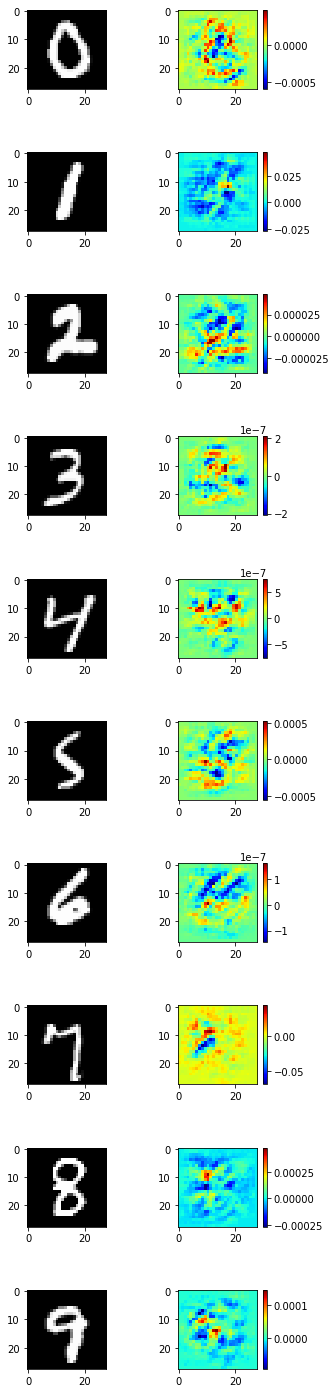

In [11]:
Y_train_label = lb.inverse_transform(Y_train)

fig, ax = plt.subplots(10, 2, figsize = (5, 25))
i=-1
for c in class_indices:
    img = np.array(X_train[c])
    i=i+1
    
    vanilla = GradientSaliency(model, Y_train_label[c])
    mask = vanilla.get_mask(img)
    filter_mask = (mask > 0.0).reshape((28, 28))
    smooth_mask = vanilla.get_smoothed_mask(img)
    filter_smoothed_mask = (smooth_mask > 0.0).reshape((28, 28))
    
    fig.subplots_adjust(hspace=.8)
    ax[i, 0].imshow(img.reshape((28, 28)), cmap = 'gray')
    cax = ax[i, 1].imshow(mask.reshape((28, 28)), cmap = 'jet')
    fig.colorbar(cax, ax = ax[i, 1])